In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="1"
import pandas as pd
import numpy as np
import random
import pickle
import re
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from datetime import datetime
from tqdm import tqdm
from sklearn.metrics import r2_score
import seaborn as sns
# from ucimlrepo import fetch_ucirepo 

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, random_split

from data.data_loader import EPCDataset, PowerWeatherDatasetWithSeason, PowerWeatherDataset, SingleTermDataset, MultiTermDataset
from models.lstm import LSTMModel
from models.lstm_attention import LSTMWithAttention, BiLSTMWithAttention
from models.gru import GRUModel
from models.utils import create_model, train_for_short_term_forecast, train_for_long_term_forecast, load_model, evaluate_for_short_term_forecast, evaluate_for_long_term_forecast

from explainers.utils import get_explainer
# from explainers.lime import LimeExplainer
# from explainers.shap import ShapExplainer
# from explainers.attention import AttentionExplainer
# from explainers.grad_cam import GradCAMExplainer
# from explainers.lrp import LRPExplainer

In [2]:
# Check if GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [3]:
# short term 
features_for_1h = [
    'Global_active_power',
    'Global_intensity',
    'Sub_metering_1', 
    'Sub_metering_2', 
    'Sub_metering_3', 
    'Temperature',	
    'Humidity',	
]

# long term
features_for_6h = [
    'Global_active_power',
    'Global_intensity',
    'Sub_metering_1', 
    'Sub_metering_2', 
    'Sub_metering_3', 
    'Temp_Min',	'Temp_Max', 'Temp_Avg',	'Temp_Range',
    'Humidity_Min',	'Humidity_Max',	'Humidity_Avg',	'Humidity_Range'
]

file_path_for_1h = 'data/final_data.csv'
file_path_for_6h = 'data/final_data_per_6hr_with_avg_range.csv'

def load_dataset(params, target_features_long, target_features_short, is_long_term_forecast=True):
    selected_features = dict()
    
    if is_long_term_forecast:
        dataset_6h = EPCDataset(
            # file_path=file_path_for_6h,
            file_path=file_path_for_1h,
            sequence_length=params['long_term_length'],  
            prediction_length=params['long_term_pred_length'],
            target_features=target_features_long
        )
        train_long, train_targets_long, eval_long, eval_targets_long = dataset_6h.load_data()
        
        dataset_1h = EPCDataset(
            file_path=file_path_for_1h,
            sequence_length=params['short_term_length'],  
            prediction_length=params['short_term_pred_length'],
            target_features=target_features_short
        )
        train_short, train_targets_short, eval_short, eval_targets_short = dataset_1h.load_data()
        
        train_data=(train_long, train_short)
        train_targets=(train_targets_long, train_targets_short)
        eval_data=(eval_long, eval_short)
        eval_targets=(eval_targets_long, eval_targets_short)

        selected_features['long'] = dataset_6h.selected_features
        selected_features['short'] = dataset_1h.selected_features

    else:
        dataset_1h = EPCDataset(
            file_path=file_path_for_1h,
            sequence_length=params['sequence_length'],  
            prediction_length=params['prediction_length'],
            target_features=target_features_short
        )
        
        train_sequence, train_targets_sequence, eval_sequence, eval_targets_sequence = dataset_1h.load_data()

        train_data=train_sequence
        train_targets=train_targets_sequence
        eval_data=eval_sequence
        eval_targets=eval_targets_sequence
    
        selected_features['single'] = dataset_1h.selected_features

    return train_data, train_targets, eval_data, eval_targets, selected_features

In [4]:
dataset_params = {
    # for long-term forecast 

    # 'long_term_length' : 365*4, # 6시간 단위 1년 데이터
    'long_term_length' : 90*24,
    'long_term_pred_length' : 256, # 64, 128, 256
    
    'short_term_length' : 30*24, # 1시간 단위 한달 데이터
    'short_term_pred_length' : 7*24, # 일주일 데이터 예측

    
    # 2. LSTM, GRU, CNN-LSTM  -> 365*24 / 7*24 (비교용)
    # for Short-term forecast 
    'sequence_length' : 24*30,  # -> 일주일 / 10일 / 15일 / 한달  
    'prediction_length' : 24
}

is_long_term_forecast = False

In [5]:
train_data, train_targets, eval_data, eval_targets, selected_features = load_dataset(params=dataset_params,
                                                                                     target_features_long=features_for_1h, 
                                                                                     target_features_short=features_for_1h, 
                                                                                     is_long_term_forecast=is_long_term_forecast)

if isinstance(train_data, tuple):
    print("1-hour data sequences for long-term forecast:")
    print(f"  Train sequences shape: {train_data[0].shape}")
    print(f"  Train targets shape: {train_targets[0].shape}")
    print(f"  Eval sequences shape: {eval_data[0].shape}")
    print(f"  Eval targets shape: {eval_targets[0].shape}")
    print(f"  Selected_features: {selected_features['long']}")
    
    print("\n1-hour data sequences for long-term forecast:")
    print(f"  Train sequences shape: {train_data[1].shape}")
    print(f"  Train targets shape: {train_targets[1].shape}")
    print(f"  Eval sequences shape: {eval_data[1].shape}")
    print(f"  Eval targets shape: {eval_targets[1].shape}")
    print(f"  Selected_features: {selected_features['short']}")
    
else:
    print("1-hour data sequences for short-term forecast:")
    print(f"  Train sequences shape: {train_data.shape}")
    print(f"  Train targets shape: {train_targets.shape}")
    print(f"  Eval sequences shape: {eval_data.shape}")
    print(f"  Eval targets shape: {eval_targets.shape}")
    print(f"  Selected_features: {selected_features['single']}")

1-hour data sequences for short-term forecast:
  Train sequences shape: torch.Size([23925, 720, 13])
  Train targets shape: torch.Size([23925, 24])
  Eval sequences shape: torch.Size([5982, 720, 13])
  Eval targets shape: torch.Size([5982, 24])
  Selected_features: ['Global_active_power', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'Temperature', 'Humidity', 'sin_hour', 'cos_hour', 'sin_day', 'cos_day', 'sin_month', 'cos_month']


In [6]:
def load_trained_model(params, selected_features):
    if params is None:
        return

    # Extract parameters
    model_name = params['model_name']
    hidden_size = params['hidden_size']
    num_layers = params['num_layers']
    dropout = params['dropout']
    num_epochs = params['num_epochs']
    batch_size = params['batch_size']
    learning_rate = params['learning_rate']
    patience = params['patience']
    mse_decay = params['mse_decay']

    if is_long_term_forecast == True:
        input_size = {
            'long': len(selected_features['long']),
            'short': len(selected_features['short']),
        }
        output_size = {
            'long': dataset_params['long_term_pred_length'],
            'short': dataset_params['short_term_pred_length'],
        }
    else:
        input_size = {
            'single': len(selected_features['single'])
        }
        output_size = {
            'single': dataset_params['prediction_length']
        }
        
    if mse_decay:
        mse_alpha = 0.3
        mse_beta = 1.0

    else:
        mse_alpha = 1.0
        mse_beta = 1.0

    # Model 생성 
    model = create_model(
        model_name=model_name,
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        output_size=output_size,
        dropout=dropout, 
        long_term_length=dataset_params['long_term_length'], 
        short_term_length=dataset_params['short_term_length']
    ) 

    if 'LS_CNNLSTM' in model_name:
        model_path = './trained_models/{}_long_{}_short_{}_{}_{}_{}_alpha_{}_beta_{}.pth'.format(
            model_name, dataset_params['long_term_length'], dataset_params['short_term_length'],
            dataset_params['long_term_pred_length'], hidden_size, num_layers, mse_alpha, mse_beta
        )
    else:
        model_path = './trained_models/{}_{}_{}_{}_{}.pth'.format(
            model_name, dataset_params['sequence_length'], dataset_params['prediction_length'],
             hidden_size, num_layers
        )
        
    print("Model path:", model_path)

    print(f"Loading the pre-trained {model_name} model...")
    model.load_state_dict(torch.load(model_path))
    model.to(torch.device('cuda' if torch.cuda.is_available() else 'cpu'))

    return model, model_path

In [7]:
model_params = {
    'model_name' : 'CNNLSTM', 
    'hidden_size' : 1024, # 256 # 512 # 1024
    'num_layers' : 3,  # 3
    'dropout' : 0.3,
    'num_epochs' : 200,
    'batch_size' : 16,
    'learning_rate' : 0.001,
    'patience' : 15,
    'mse_decay' : True   # 고정, 가중치 변화
}

model, model_path = load_trained_model(model_params, selected_features)

# print("Evaluating the model...")
# if is_long_term_forecast:
#     results = evaluate_for_long_term_forecast(
#         model=model,
#         eval_data=eval_data,
#         eval_targets=eval_targets,
#         model_name=model_params['model_name'],
#         batch_size=model_params['batch_size'], 
#         oversample_eval=True 
#     )
# else:
#     results = evaluate_for_short_term_forecast(
#         model=model,
#         eval_sequences=eval_data,
#         eval_targets=eval_targets,
#         model_name=model_params['model_name'],
#         batch_size=model_params['batch_size']
#     )

Model path: ./trained_models/CNNLSTM_720_24_1024_3.pth
Loading the pre-trained CNNLSTM model...


/tmp/ipykernel_1042802/3342642552.py:67: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


In [8]:
important_features_dict = {}


if isinstance(train_data, tuple):
    num_samples=len(eval_data[0])
else:
    num_samples=eval_data.shape[0]
    
num_samples=1000
print('num_samples: ', num_samples)


top_n=len(features_for_1h)

if is_long_term_forecast:
    sequence_length = {
        'long': dataset_params['long_term_length'],
        'short': dataset_params['short_term_length']
    }
    input_size = {
        # 'long': len(features_for_6h)+6,
        'long': len(features_for_1h)+6,
        'short': len(features_for_1h)+6,
        'single': len(features_for_1h)+6
    }
    output_size = {
        'long': dataset_params['long_term_pred_length'],
        'short': dataset_params['short_term_pred_length'],
        'single': dataset_params['prediction_length']
    }
else:
    sequence_length = {
        'single': dataset_params['sequence_length']
    }
    input_size = {
        'single': len(features_for_1h)+6
    }
    output_size = {
        'single': dataset_params['prediction_length']
    }

num_samples:  1000


In [9]:
# 우선 단기 전력 예측에 대해서 적용
## 장기로 바꾸려면 sequnce_legnth와 input_size가 long/short 키에 대해 두개인거로 고려해야됨

explainer_type = 'SHAP' 
explainer = get_explainer(explainer_type=explainer_type, 
                          model=model,
                          device=device, 
                          train_data=train_data, 
                          sequence_length=sequence_length['single'],
                          input_size=input_size['single'],
                          selected_features=selected_features['single'])

/archive/workspace/XAI/co-work/explainers/shap.py:38: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  background_data = torch.tensor(self.train_sequences[:num_train_sample],


In [10]:
num_samples = 1
shap_values, sampled_eval_sequences = explainer.explain_DeepExplainer(eval_data, 
                                                                      num_samples=num_samples)

/archive/workspace/XAI/co-work/explainers/shap.py:47: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  random_samples_tensor = torch.tensor(random_samples, dtype=torch.float32).to(self.device)
/archive/library/anaconda3/envs/xai/lib/python3.11/site-packages/shap/explainers/_deep/deep_pytorch.py:243: UserWarning: unrecognized nn.Module: LSTM
  warnings.warn(f'unrecognized nn.Module: {module_type}')


Summary plot


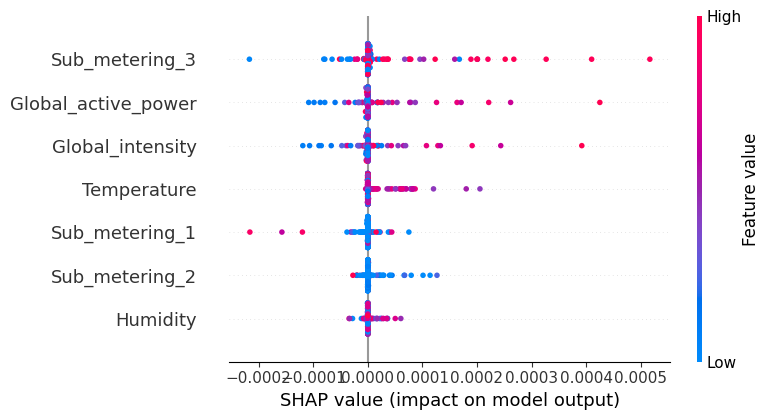

Dependence plot: Global_active_power (target output index: 0)


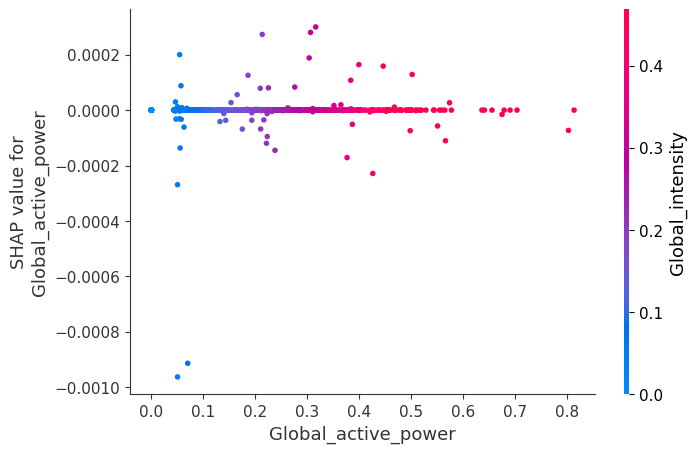

Dependence plot: Sub_metering_3 (target output index: 0)


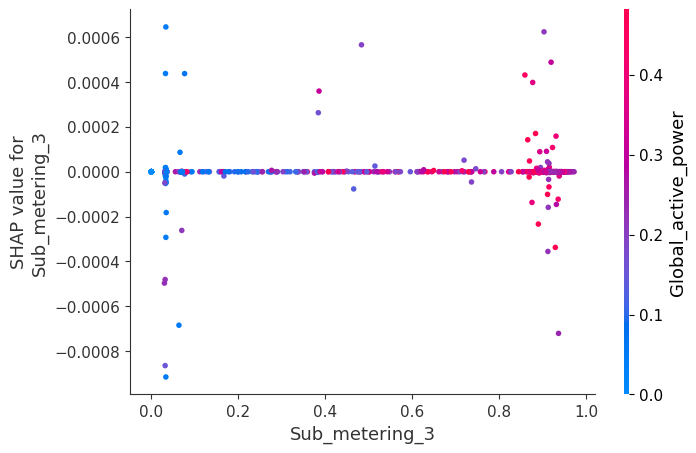

Dependence plot: Humidity (target output index: 0)


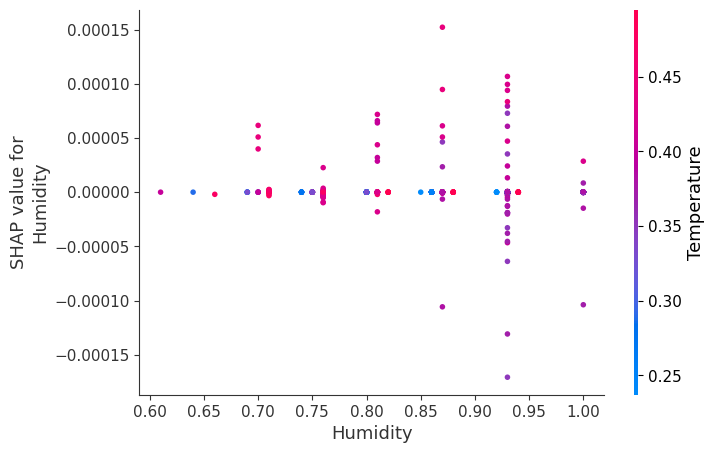

Dependence plot: Temperature (target output index: 0)


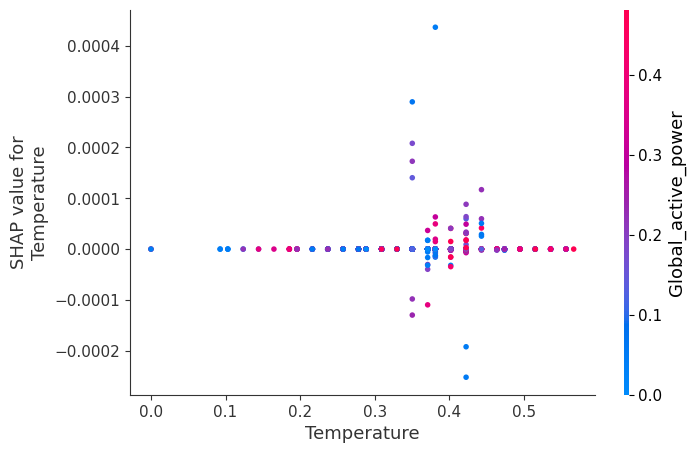

In [11]:
explainer.visualize_all_one_sample(shap_values[0], 
                                   sampled_eval_sequences[0], 
                                   target_f_idx1=0,
                                   target_f_idx2=1,
                                   target_idx=0)

✅ 1. Global_active_power vs. Global_intensity

해석: Global_active_power가 증가할수록 Global_intensity 값도 함께 증가하는 경향이 뚜렷하게 나타납니다.

SHAP 값 해석: 둘 다 모델의 주요 feature이며, 이 조합은 상호 연관성이 강하기 때문에 모델 예측에 미치는 영향이 뚜렷하게 시각화됨.

적합성: 전력량과 전류 강도는 물리적으로 연결되어 있으므로, 이 관계를 보여주는 것은 모델의 물리 기반 설명력 강화에 도움이 됩니다.

✅ 논문 포함 추천.

✅ 2. Sub_metering_3 vs. Global_active_power

해석: Sub_metering_3 값이 높을수록 Global_active_power가 상대적으로 높은 색으로 분포되며, SHAP 값도 약간 증가함.

SHAP 값 해석: Sub_metering_3은 특정 가전 전력 소비를 나타내며, Global_active_power와의 양의 관계는 해당 전력이 총 소비에 기여한다는 점에서 설득력 있음.

적합성: 지역(sub) 소비가 전체 소비에 기여한다는 점을 강조할 수 있는 유의미한 결과.

✅ 논문 포함 추천.

✅ 3. Humidity vs. Temperature

해석: Humidity가 0.85 이상일 때 일부 Temperature가 높은 구간에서 SHAP 값이 증가함. 전력 소비 예측에서 온습도는 계절/시간대 영향 반영 가능.

SHAP 값 해석: 전력 예측이 단순 전기 사용량 외에 기후 환경의 영향을 받는다는 정성적 근거 제공.

적합성: 특히 여름/겨울철 전력 소비 분석 시 외부 환경 요인 반영으로 유용함.

✅ 논문 포함 추천, 다만 온도/습도 관련 해석은 시계열 정보와 함께 보완되면 더 효과적.


✅ 5. Temperature vs Global_active_power
해석:

Temperature의 값이 높아질수록 SHAP 값이 약간 양의 방향으로 증가.

특히 Global_active_power가 높은 샘플에서 SHAP 기여가 눈에 띄게 높아짐.

컬러 바와의 연계성(색에 따른 Global_active_power)이 잘 드러남.

평가:

의미 있는 상관관계를 시각적으로 표현함.

모델이 기온이 높은 상황에서 전력 사용량에 더 민감하게 반응할 수 있음을 시사.


